In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('dados/banking.db')

financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'CONTA', 'NOME_CONTA', 'saldo_medio']

query = f"""
SELECT 
    {', '.join(financial_indicators)} 
FROM 
    balancetes_media_ano
WHERE 
    cnpj IN (
        SELECT cnpj
        FROM balancetes_media_ano
        GROUP BY ano, cnpj
    );"""

df = pd.read_sql_query(query, conn)

conn.close()

df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

df['nome_conta'] = (df['nome_conta']
                      .str.lower()
                      .str.normalize('NFD')
                      .str.replace(r'[\u0300-\u036f]', '', regex=True))



In [2]:
# 1. Agrupar e contar valores únicos
inconsistencias = df.groupby('conta')['nome_conta'].nunique()

# 2. Filtrar apenas onde a contagem é > 1
contas_duplicadas = inconsistencias[inconsistencias > 1].index

# 3. Visualizar os dados problemáticos
df_problema = df[df['conta'].isin(contas_duplicadas)].sort_values(by='conta')

print(f"Total de contas com nomes divergentes: {len(contas_duplicadas)}")

Total de contas com nomes divergentes: 39


In [3]:
# Padronizando nomes
df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"



In [4]:
# 1. Agrupar e contar valores únicos
inconsistencias = df.groupby('nome_conta')['conta'].nunique()

# 2. Filtrar apenas onde a contagem é > 1
contas_duplicadas = inconsistencias[inconsistencias > 1].index

# 3. Visualizar os dados problemáticos
df_problema = df[df['nome_conta'].isin(contas_duplicadas)].sort_values(by='nome_conta')

print(f"Total de contas com nomes divergentes: {len(contas_duplicadas)}")

# 1. Primeiro, pegamos apenas os pares únicos de conta/nome para limpar repetições exatas
pares_unicos = df[['conta', 'nome_conta']].drop_duplicates()

# 2. Agora, verificamos quais 'conta' ainda aparecem duplicadas (indicando nomes diferentes)
mascara_inconsistencia = pares_unicos.duplicated(subset=['nome_conta'], keep=False)

# 3. Filtramos e mostramos o resultado
tabela_inconsistencias = pares_unicos[mascara_inconsistencia].sort_values(by='nome_conta')


Total de contas com nomes divergentes: 21


In [5]:
# Conta duplicada
df = df[df['conta'] != 88000008]
df = df[df['conta'] != 47100004]
df = df[df['conta'] != 51100007]
df = df[df['conta'] != 78100004]
df = df[df['conta'] != 61000001]



In [6]:
mapa_contas = (
    df.groupby('conta')['nome_conta']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

novo_mapeamento = {}

for conta, nome in mapa_contas.items():
    conta_str = str(conta) # Garante que podemos verificar o início
    
    if conta_str.startswith('1'):
        novo_nome = f"ativo realizavel - {nome}"
    elif conta_str.startswith('2'):
        novo_nome = f"ativo permanente - {nome}"
    elif conta_str.startswith('3'):
        novo_nome = f"compensacao ativa - {nome}"
    elif conta_str.startswith('4'):
        novo_nome = f"passivo exigivel - {nome}"
    elif conta_str.startswith('6'):
        novo_nome = f"patrimonio liquido - {nome}"
    elif conta_str.startswith('7'):
        novo_nome = f"resultado credor - {nome}"
    elif conta_str.startswith('8'):
        novo_nome = f"resultado devedor - {nome}"
    elif conta_str.startswith('9'):
        novo_nome = f"compensacao passiva - {nome}"
    else:
        novo_nome = nome # Mantém o original se não houver regra
        
    novo_mapeamento[conta] = novo_nome

mapa_contas = novo_mapeamento



In [7]:

df = df.pivot(
    index=['ano', 'cnpj', 'nome'],
    columns='conta',
    values='saldo'
).reset_index()

# Valor mínimo da conta operações de crédito
df = df[df[16000001] > 1000000]


In [8]:
# Dividindo os valores pelo Ativo Total (39999993)
colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 39999993]]
for col in colunas_a_dividir:
    df[col] = df[col] / df[39999993]
df.drop(columns=[39999993, 99999995], inplace=True)
df_filtrado = df

df = df.rename(columns=novo_mapeamento)


In [9]:
# Selecionando contas para o clustering
'''contas_selecionadas = [
    'ativo realizavel - ativo realizavel',
    'ativo realizavel - disponibilidades',
    'ativo realizavel - operacoes de credito',
    'ativo realizavel - negociacao e intermediacao de valores',
    'ativo realizavel - titulos e valores mobiliarios e instrumentos financeiros derivativos',
    'resultado credor - rendas de participacoes',
    'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais',
    'ativo realizavel - (-) provisoes para operacoes de credito',
    'ativo realizavel - reservas livres', 
    'ativo realizavel - vinculados a prestacao de garantias', 
    'ativo realizavel - rendas a receber'
    ]

df  = df[['ano', 'cnpj', 'nome'] + contas_selecionadas]
'''

"contas_selecionadas = [\n    'ativo realizavel - ativo realizavel',\n    'ativo realizavel - disponibilidades',\n    'ativo realizavel - operacoes de credito',\n    'ativo realizavel - negociacao e intermediacao de valores',\n    'ativo realizavel - titulos e valores mobiliarios e instrumentos financeiros derivativos',\n    'resultado credor - rendas de participacoes',\n    'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais',\n    'ativo realizavel - (-) provisoes para operacoes de credito',\n    'ativo realizavel - reservas livres', \n    'ativo realizavel - vinculados a prestacao de garantias', \n    'ativo realizavel - rendas a receber'\n    ]\n\ndf  = df[['ano', 'cnpj', 'nome'] + contas_selecionadas]\n"

In [10]:
# Eliminando colunas esparsas

# 1. Calcular a porcentagem de nulos em cada coluna
#esparsidade = df.isnull().sum() / len(df)
esparsidade = (df.isnull() | (df == 0)).sum() / len(df)
# 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
print(f"Colunas com > 10% de nulos: {sum(esparsidade > 0.10)}")
print(f"Colunas com > 20% de nulos: {sum(esparsidade > 0.20)}")
print(f"Colunas com > 30% de nulos: {sum(esparsidade > 0.30)}")

# 3. Definir o limiar
limiar_corte = 0.30

# Identificar colunas a serem removidas
colunas_para_remover = esparsidade[esparsidade > limiar_corte].index
colunas_para_remover = [col for col in colunas_para_remover if col not in ['ano', 'cnpj', 'nome']]
# 4. Criar o novo dataset filtrado
df_filtrado = df.drop(columns=colunas_para_remover)

print(f"\nDimensão original: {df.shape[1]} colunas")
print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
df_filtrado.fillna(0, inplace=True)


Colunas com > 10% de nulos: 171
Colunas com > 20% de nulos: 161
Colunas com > 30% de nulos: 152

Dimensão original: 208 colunas
Dimensão após corte de esparsidade: 55 colunas


<Axes: xlabel='conta', ylabel='conta'>

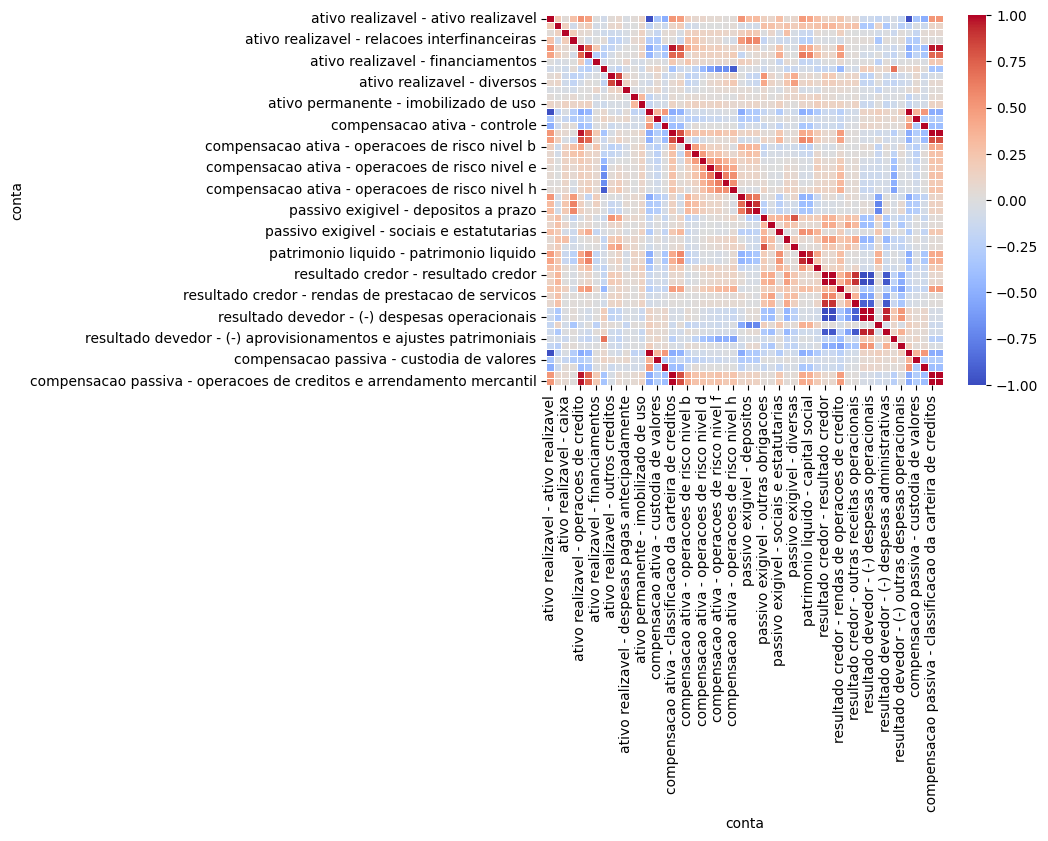

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit the scaler to the data and transform the data
# X_scaled will be a NumPy array, not a DataFrame
X = df_filtrado.drop(columns=['ano', 'cnpj', 'nome'], axis=1)
variaveis = pd.DataFrame({'Contas': [col for col in X.columns]})
# X.dropna(axis=1, inplace=True)
X.fillna(0, inplace=True)

corr_matrix = X.corr(method='pearson')

# Usar um heatmap do seaborn
# Cmap='coolwarm' é ótimo, pois destaca cores diferentes para correlação positiva e negativa
sns.heatmap(
    corr_matrix, 
    annot=False,            # Não mostrar os números (seria ilegível com 159)
    cmap='coolwarm', 
    fmt=".2f",              # Formato de duas casas decimais
    linewidths=.5,          # Linhas entre as células
    vmin=-1, vmax=1         # Definir escala de -1 a 1
)


In [12]:
# 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
corr_matrix_abs = corr_matrix.abs()

# 2. Selecionar apenas o triângulo superior da matriz
# Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 3. Definir o Limiar de Corte (Threshold)
# 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
threshold = 0.95

# Encontrar colunas que têm correlação > threshold com qualquer outra coluna
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
print(to_drop)

# Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
#X.drop(columns=to_drop, inplace=True)

X.columns = X.columns.astype(str)
X_scaled = scaler.fit_transform(X)

# Optional: Convert back to a DataFrame for easier handling, using the original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)




--- Contas Redundantes a Descartar (Correlação > 0.95) ---
Número de variáveis sugeridas para remoção: 10
['compensacao ativa - compensacao ativa', 'compensacao ativa - classificacao da carteira de creditos', 'resultado credor - receitas operacionais', 'resultado devedor - (-) resultado devedor', 'resultado devedor - (-) despesas operacionais', 'compensacao passiva - compensacao passiva', 'compensacao passiva - custodia de valores', 'compensacao passiva - controle', 'compensacao passiva - classificacao da carteira de creditos', 'compensacao passiva - operacoes de creditos e arrendamento mercantil']


In [13]:
'''import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 2. Ajustar o PCA sem limitar componentes (para análise)
pca_analise = PCA()
pca_analise.fit(X_scaled)

# Calcular a variância acumulada
variancia_acumulada = np.cumsum(pca_analise.explained_variance_ratio_)

# Plotar o gráfico para decisão visual
plt.figure(figsize=(10, 6))
plt.plot(variancia_acumulada, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Análise de Variância do PCA')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='Limiar de 90%') # Linha de corte
plt.legend()
plt.show()

# Calcular matematicamente o número ideal (k) para 90% de variância
variancia = 0.9
k_ideal = np.argmax(variancia_acumulada >= variancia) + 1
print(f"Número ideal de componentes para reter {100*variancia}% da informação: {k_ideal}")'''

'import matplotlib.pyplot as plt\nfrom sklearn.decomposition import PCA\n\n# 2. Ajustar o PCA sem limitar componentes (para análise)\npca_analise = PCA()\npca_analise.fit(X_scaled)\n\n# Calcular a variância acumulada\nvariancia_acumulada = np.cumsum(pca_analise.explained_variance_ratio_)\n\n# Plotar o gráfico para decisão visual\nplt.figure(figsize=(10, 6))\nplt.plot(variancia_acumulada, marker=\'o\', linestyle=\'--\')\nplt.xlabel(\'Número de Componentes\')\nplt.ylabel(\'Variância Explicada Acumulada\')\nplt.title(\'Análise de Variância do PCA\')\nplt.grid(True)\nplt.axhline(y=0.95, color=\'r\', linestyle=\'-\', label=\'Limiar de 90%\') # Linha de corte\nplt.legend()\nplt.show()\n\n# Calcular matematicamente o número ideal (k) para 90% de variância\nvariancia = 0.9\nk_ideal = np.argmax(variancia_acumulada >= variancia) + 1\nprint(f"Número ideal de componentes para reter {100*variancia}% da informação: {k_ideal}")'

In [14]:
'''# 3. Aplicar o PCA com o número de componentes escolhido
pca_final = PCA(n_components=k_ideal)
X_pca = pca_final.fit_transform(X_scaled)

features = X.columns.tolist()

# Criar um DataFrame com os pesos (Loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(k_ideal)], 
    index=features
)

#loadings.to_csv('loadings.csv', index=False)
# Para cada Componente Principal, ver as 5 variáveis mais influentes
for i in range(3): # Vamos olhar só os 3 primeiros componentes como exemplo
    coluna = f'PC{i+1}'
    print(f"\n--- Principais influenciadores do {coluna} ---")
    # Ordenar pelo valor absoluto do peso
    top_features = loadings[coluna].abs().sort_values(ascending=False).head(5)
    
    # Mostrar a feature e se a correlação é positiva ou negativa
    for feature, peso in top_features.items():
        sinal = "+" if loadings.loc[feature, coluna] > 0 else "-"
        print(f"{feature}: {sinal} ({loadings.loc[feature, coluna]:.4f})")
    '''

'# 3. Aplicar o PCA com o número de componentes escolhido\npca_final = PCA(n_components=k_ideal)\nX_pca = pca_final.fit_transform(X_scaled)\n\nfeatures = X.columns.tolist()\n\n# Criar um DataFrame com os pesos (Loadings)\nloadings = pd.DataFrame(\n    pca_final.components_.T, \n    columns=[f\'PC{i+1}\' for i in range(k_ideal)], \n    index=features\n)\n\n#loadings.to_csv(\'loadings.csv\', index=False)\n# Para cada Componente Principal, ver as 5 variáveis mais influentes\nfor i in range(3): # Vamos olhar só os 3 primeiros componentes como exemplo\n    coluna = f\'PC{i+1}\'\n    print(f"\n--- Principais influenciadores do {coluna} ---")\n    # Ordenar pelo valor absoluto do peso\n    top_features = loadings[coluna].abs().sort_values(ascending=False).head(5)\n\n    # Mostrar a feature e se a correlação é positiva ou negativa\n    for feature, peso in top_features.items():\n        sinal = "+" if loadings.loc[feature, coluna] > 0 else "-"\n        print(f"{feature}: {sinal} ({loadings.loc

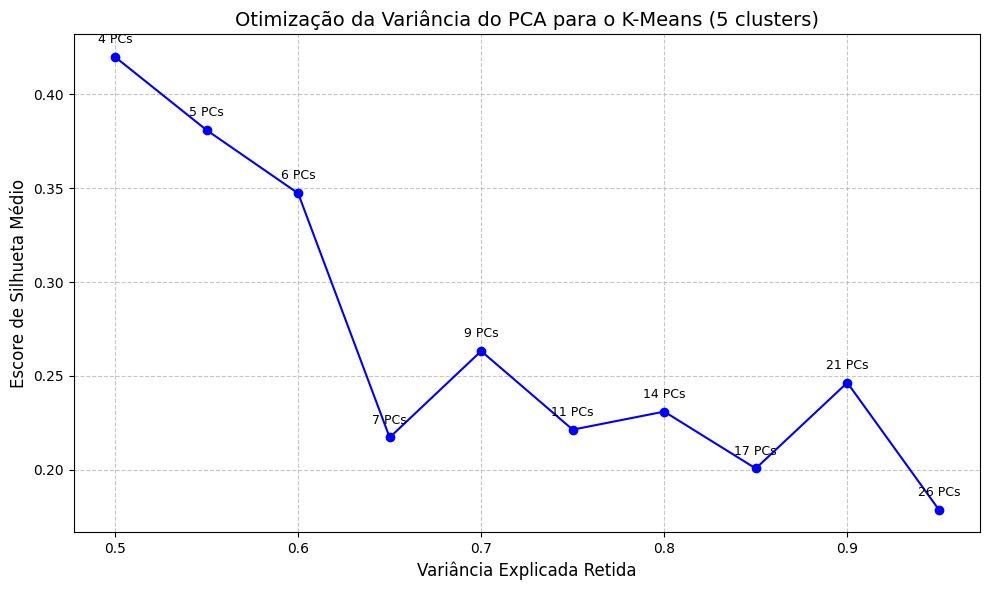

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

numero_de_clusters = 5

# 1. Definimos a grade de variâncias que queremos testar (de 60% a 95%, pulando de 5 em 5)
niveis_variancia = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

# Listas vazias para guardar os resultados
escores_silhueta = []
qnt_componentes = []

# 2. O Loop de Experimentação
for var in niveis_variancia:
    # A. Roda o PCA para o nível de variância atual da repetição
    pca_test_silhoutte = PCA(n_components=var, random_state=42)
    dados_pca = pca_test_silhoutte.fit_transform(X_scaled)
    
    # Guarda quantos componentes o PCA precisou para atingir essa variância
    qnt_componentes.append(pca_test_silhoutte.n_components_)
    
    # B. Roda o K-Means nos dados reduzidos
    kmeans = KMeans(n_clusters=numero_de_clusters, random_state=42)
    kmeans.fit(dados_pca)
    
    # C. Calcula e guarda o Escore de Silhueta
    score = silhouette_score(dados_pca, kmeans.labels_)
    escores_silhueta.append(score)

# 3. Visualizando os Resultados
plt.figure(figsize=(10, 6))

# Plota a linha principal (Variância vs Silhueta)
plt.plot(niveis_variancia, escores_silhueta, marker='o', linestyle='-', color='b')

# Adiciona o número de componentes como rótulo em cada ponto para facilitar sua vida
for i, txt in enumerate(qnt_componentes):
    plt.annotate(f"{txt} PCs", (niveis_variancia[i], escores_silhueta[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title(f'Otimização da Variância do PCA para o K-Means ({numero_de_clusters} clusters)', fontsize=14)
plt.xlabel('Variância Explicada Retida', fontsize=12)
plt.ylabel('Escore de Silhueta Médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [16]:
num_componentes_pca = 20
pca_final = PCA(n_components=num_componentes_pca) # num de componentes do PCA
X_pca = pca_final.fit_transform(X_scaled)

features = X.columns.tolist()

# Criar um DataFrame com os componentes principais de cada instituição
# Gerar dinamicamente os nomes das colunas: 'PC1', 'PC2', 'PC3', etc.
nomes_componentes = [f'PC{i+1}' for i in range(X_pca.shape[1])]

# 5. Converter o array do PCA de volta para DataFrame do Pandas
df_pca_puro = pd.DataFrame(
    X_pca, 
    columns=nomes_componentes, 
    index=df_filtrado.index # Mantém a mesma ordem das linhas original
)
df_var_pca = df_pca_puro.var()

# 6. Colar os identificadores ao lado dos componentes
df_pca_valores = pd.concat([df_filtrado[['ano', 'cnpj', 'nome']], df_pca_puro], axis=1)

# Criar um DataFrame com os pesos (Loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(num_componentes_pca)], 
    index=features
)

# 1. Extrair a porcentagem de relevância de CADA componente do PCA
relevancia_individual = pca_final.explained_variance_ratio_

# 2. Calcular a relevância ACUMULADA (soma progressiva)
relevancia_acumulada = np.cumsum(relevancia_individual)

# 3. Criar uma tabela bonita para visualizar (DataFrame Pandas)
pca_relevancia = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(relevancia_individual))],
    'Variância Individual (%)': np.round(relevancia_individual * 100, 2),
    'Variância Acumulada (%)': np.round(relevancia_acumulada * 100, 2)
})

In [17]:
import numpy as np
import pandas as pd
# Analisando bancos atípicos (Outliers) usando o PCA

# 1. Definir o limite de desvios padrões (3 é o padrão de mercado)
limite_desvios = 4

df_pca = pd.DataFrame(X_pca)
df_pca = df_pca[[0, 1]]
# 3. Calcular a distância em Desvios Padrões (Z-score absoluto)
# A fórmula é: | (valor - média) / desvio_padrao |
z_scores = np.abs((df_pca - df_pca.mean()) / df_pca.std())

# 4. Criar uma "máscara" (Filtro)
# A função .any(axis=1) verifica se a instituição estourou o limite em PELO MENOS UM dos componentes
mascara_outliers = (z_scores > limite_desvios).any(axis=1)

# 5. Extrair os Outliers (Os bancos atípicos)
bancos_outliers = df_pca[mascara_outliers]

# 6. Extrair os Inliers (A base limpa para o K-Means)
bancos_normais = df_pca[~mascara_outliers] # O símbolo ~ inverte o filtro


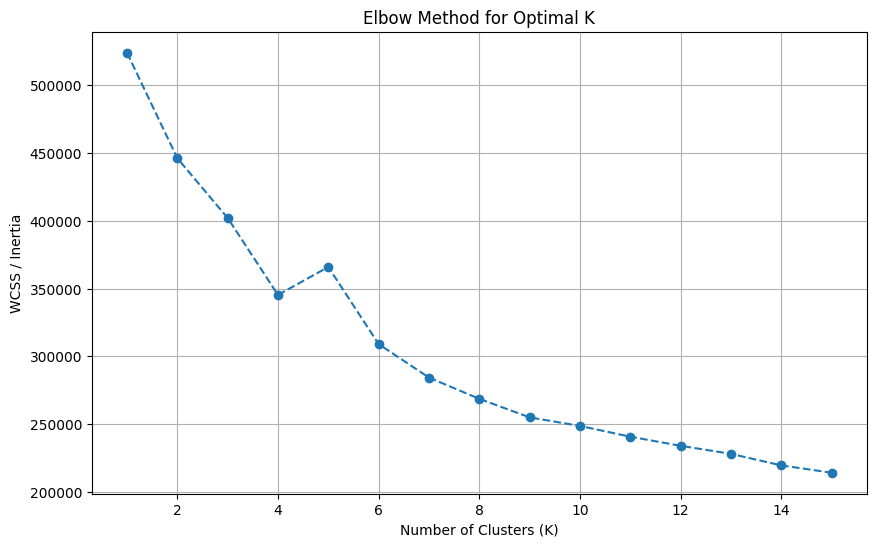

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define the range of K to test (e.g., from 1 to 15 clusters)
max_k = 15
wcss = [] # Within-Cluster Sum of Squares

for i in range(1, max_k + 1):
    # Use n_init='auto' for robustness and random_state for reproducibility
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()

--- Estatística de Hartigan para Escolha de K ---
     K  Estatística_Hartigan  Redução_Percentual
0    2                  0.11               10.95
1    3                  0.16               16.43
2    4                 -0.06               -5.62
3    5                  0.18               18.38
4    6                  0.09                8.68
5    7                  0.06                5.84
6    8                  0.05                5.35
7    9                  0.03                2.54
8   10                  0.03                3.29
9   11                  0.03                2.88
10  12                  0.03                2.60
11  13                  0.04                3.87
12  14                  0.03                2.53


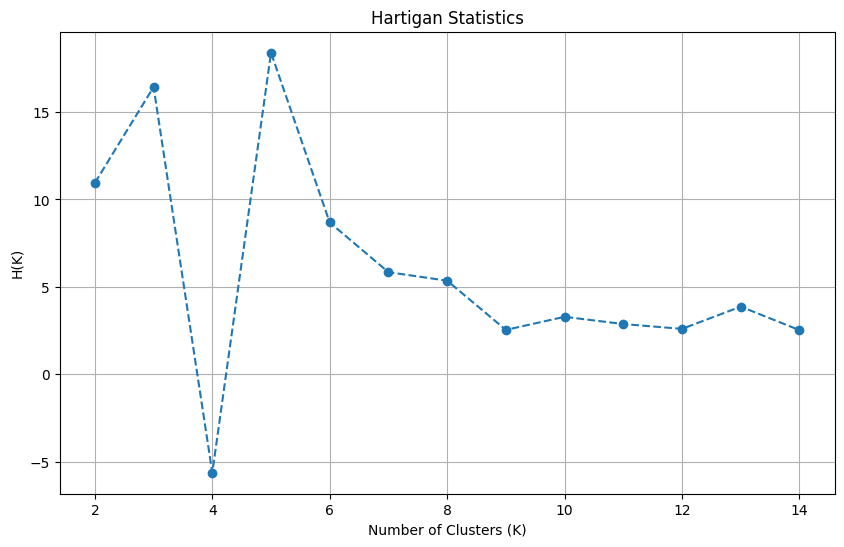

In [19]:
hartigan_stats = {}
max_k = len(wcss)

for k in range(2, max_k):
    wcss_k = wcss[k-1]
    wcss_k_plus_1 = wcss[k]

    hartigan = (wcss_k - wcss_k_plus_1) / wcss_k_plus_1
    
    hartigan_stats[k] = hartigan

hartigan_df = pd.DataFrame(
    list(hartigan_stats.items()), 
    columns=['K', 'Estatística_Hartigan']
)

hartigan_df['Redução_Percentual'] = hartigan_df['Estatística_Hartigan'] * 100

print("--- Estatística de Hartigan para Escolha de K ---")
print(hartigan_df.round(2))

plt.figure(figsize=(10, 6))
plt.plot(hartigan_df['K'], hartigan_df['Redução_Percentual'], marker='o', linestyle='--')
plt.title('Hartigan Statistics')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('H(K)')
plt.grid(True)
plt.show()

In [20]:
optimal_k = numero_de_clusters

# Initialize and train the final model
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
final_kmeans.fit(X_pca)

# Get the cluster labels for each bank
cluster_labels = final_kmeans.labels_

In [21]:
# 1. Add the cluster labels to the original DataFrame
df_filtrado['Cluster'] = cluster_labels
df_filtrado.columns = df_filtrado.columns.astype(str)

# 2. Profile the clusters by calculating the mean of the original (unscaled) features for each cluster
cluster_profiles = df_filtrado.groupby('Cluster')[X.columns].mean().sort_values(by='ativo realizavel - operacoes de credito', ascending=False)


print("\n--- Cluster Profiles (Centroid Means) ---")
print(cluster_profiles)

# 3. Save the results to a new CSV or update the SQLite database
df_filtrado[['cnpj', 'Cluster']].to_csv('bank_clusters.csv', index=False)
cluster_profiles.to_csv('cluster_profiles.csv', index=False)
# You can now use the 'Cluster' column as a categorical variable or for segmentation in your Ho and Saunders model.

coluna_para_mover = df_filtrado.pop('Cluster')

df_filtrado.insert(3, 'Cluster', coluna_para_mover)



--- Cluster Profiles (Centroid Means) ---
conta    ativo realizavel - ativo realizavel  \
Cluster                                        
2                                   0.485445   
3                                   0.435607   
0                                   0.557166   
1                                   0.250320   
4                                   0.222072   

conta    ativo realizavel - disponibilidades  ativo realizavel - caixa  \
Cluster                                                                  
2                                   0.020450                  0.000498   
3                                   0.005037                  0.002916   
0                                   0.005993                  0.002314   
1                                   0.002919                  0.002324   
4                                   0.002908                  0.000300   

conta    ativo realizavel - relacoes interfinanceiras  \
Cluster                                     

<Axes: xlabel='cluster_proximo_ano', ylabel='Cluster'>

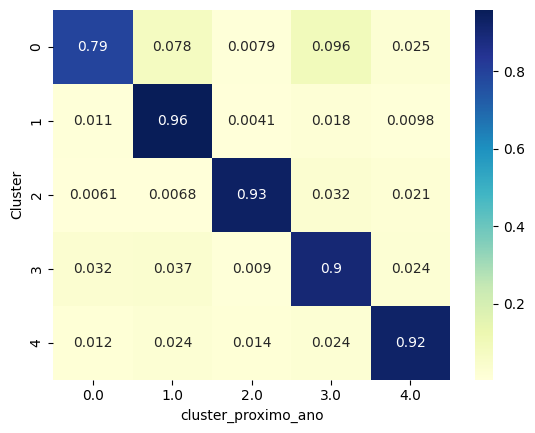

In [22]:
# 1. Criar uma coluna com o cluster do ano seguinte para cada banco
df_sorted = df_filtrado.sort_values(['cnpj', 'ano'])
df_sorted['cluster_proximo_ano'] = df_sorted.groupby('cnpj')['Cluster'].shift(-1)

# 2. Criar a matriz de contagem/frequência
matriz_transicao = pd.crosstab(
    df_sorted['Cluster'], 
    df_sorted['cluster_proximo_ano'], 
    normalize='index' # Transforma em porcentagem
)

import seaborn as sns
sns.heatmap(matriz_transicao, annot=True, cmap='YlGnBu')

In [23]:
# Quantos clusters diferentes cada banco já visitou?
mudancas_por_banco = df_filtrado.groupby('cnpj')['Cluster'].nunique()

print(f"Bancos que nunca mudaram de cluster: {sum(mudancas_por_banco == 1)}")
print(f"Bancos que já estiveram em 2 ou mais clusters: {sum(mudancas_por_banco > 1)}")

# Ver quem são os bancos que mais mudam
bancos_instaveis = mudancas_por_banco[mudancas_por_banco > 1].index

Bancos que nunca mudaram de cluster: 947
Bancos que já estiveram em 2 ou mais clusters: 423


In [24]:
X_var = X.var()


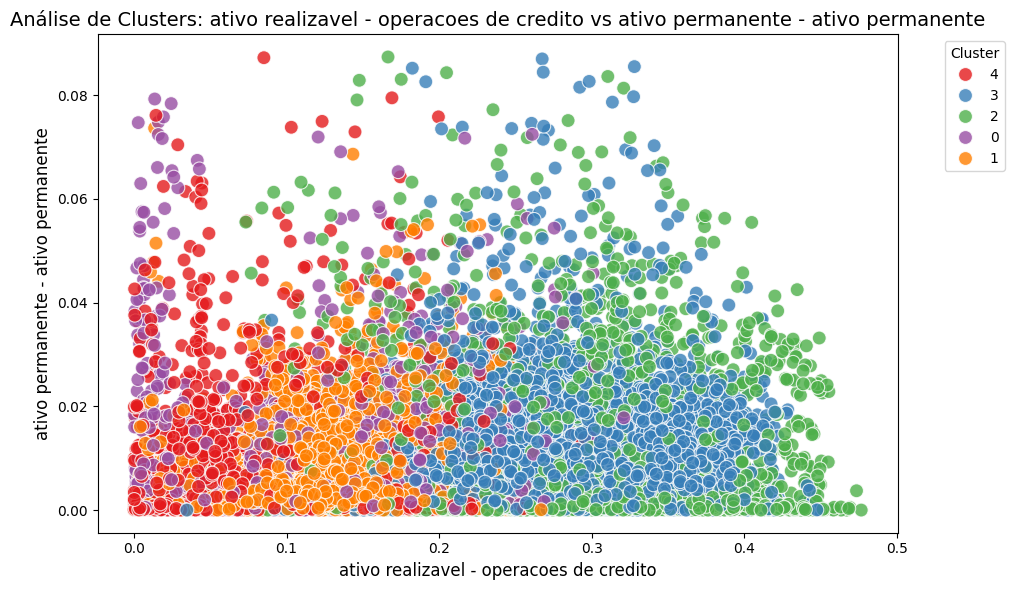

In [25]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd

# 1. Preparação dos Dados
# Supondo que 'df_filtrado' seja o seu DataFrame com as proporções (ANTES do Z-score e PCA)
# e que 'final_kmeans' seja o seu modelo K-Means já treinado.

# Criamos uma cópia para não alterar a base df_filtrado acidentalmente
df_viz = df_filtrado.copy()

# Adicionamos uma nova coluna com os rótulos dos clusters gerados pelo K-Means
# Transformamos em string (texto) para que o Seaborn entenda como categorias, não como números contínuos
df_viz['Cluster'] = final_kmeans.labels_.astype(str)

# 2. Configuração do Gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura (largura, altura)

# 3. Criando o Gráfico de Dispersão (Scatter Plot)
# Escolha o par de contas do COSIF que você quer cruzar
conta_x = 'ativo realizavel - operacoes de credito'
conta_y = 'ativo permanente - ativo permanente'

# Filtra mantendo apenas quem tem Z-score < 3 nos dois eixos
df_viz = df_viz[
    (np.abs(stats.zscore(df_viz[conta_x])) < 3) &
    (np.abs(stats.zscore(df_viz[conta_y])) < 3)
]

sns.scatterplot(
    data=df_viz, 
    x=conta_x, 
    y=conta_y, 
    hue='Cluster',        # Define a cor baseada na coluna 'Cluster'
    palette='Set1',       # Paleta de cores bem distinta
    s=100,                # Tamanho dos pontos
    alpha=0.8             # Transparência dos pontos (útil se houver sobreposição)
)

# 4. Ajustes estéticos (Títulos e Eixos)
plt.title(f'Análise de Clusters: {conta_x} vs {conta_y}', fontsize=14)
plt.xlabel(conta_x, fontsize=12)
plt.ylabel(conta_y, fontsize=12)

# Move a legenda para fora do gráfico para não cobrir os dados
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Otimiza o layout e exibe o gráfico
plt.tight_layout()
plt.show()

<Axes: xlabel='ano'>

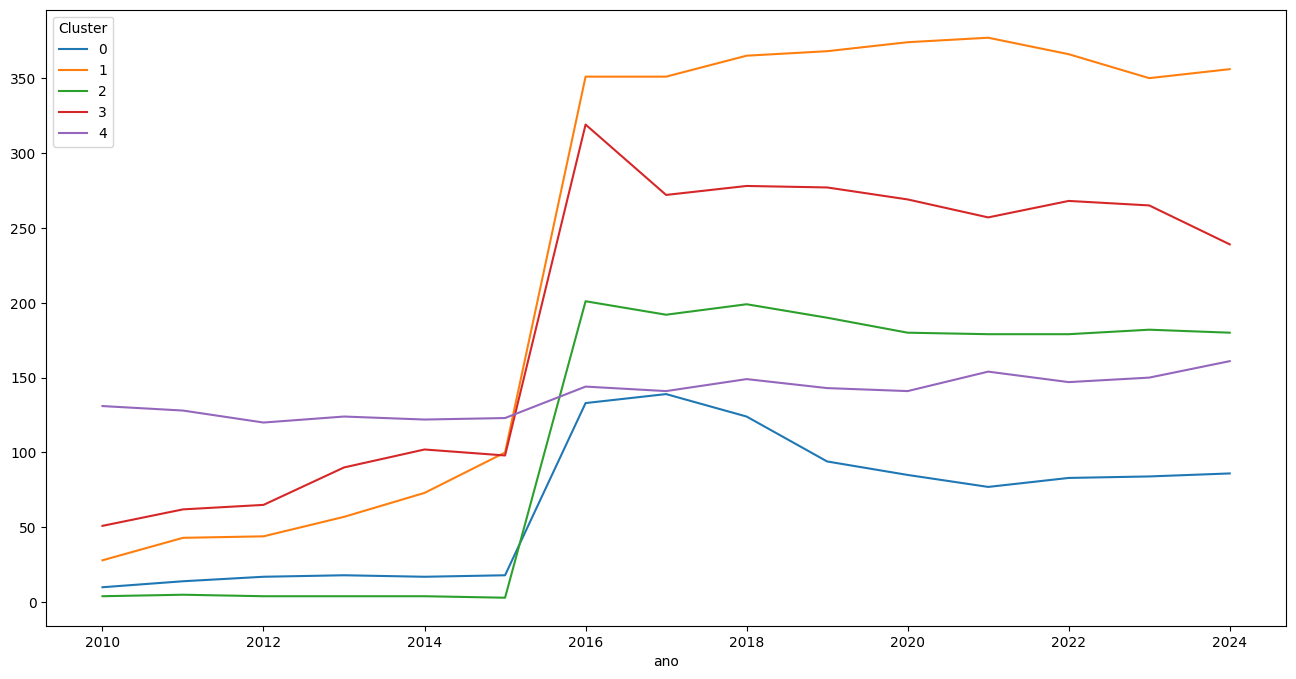

In [26]:
# Ver a evolução da quantidade de bancos em cada cluster por ano
evolucao_clusters = df_filtrado.groupby(['ano', 'Cluster']).size().unstack().fillna(0)
evolucao_clusters.plot(kind='line', stacked=False, marker='', figsize=(16,8))

In [27]:
# Bancos que mudaram para o df_filtrado em 2018
cluster_alvo = 2 # Substitua pelo número do cluster que aumentou
bancos_2017 = set(df_filtrado[df_filtrado['ano'] == '2015']['cnpj'])
bancos_2018 = set(df_filtrado[df_filtrado['ano'] == '2016']['cnpj'])

novos_no_cluster = df_filtrado[(df_filtrado['ano'] == '2016') & (df_filtrado['Cluster'] == cluster_alvo)]
migrantes = novos_no_cluster[novos_no_cluster['cnpj'].isin(bancos_2017)]
entrantes_puros = novos_no_cluster[~novos_no_cluster['cnpj'].isin(bancos_2017)]

print(f"Bancos que migraram de outros clusters: {len(migrantes)}")
print(f"Novos bancos que já entraram nesse cluster: {len(entrantes_puros)}")

Bancos que migraram de outros clusters: 4
Novos bancos que já entraram nesse cluster: 197


In [28]:
# Encontrando as médias dos indicadores a cada ano para cada cluster

cluster_alvo = 0  # Substitua pelo número do cluster que aumentou
comparativo = df_filtrado[df_filtrado['Cluster'] == cluster_alvo].groupby('ano')[variaveis['Contas']].mean()


In [29]:
'''
from sqlalchemy import create_engine

k_means_clusters = df_filtrado[['ano', 'cnpj', 'Cluster']]
engine = create_engine('sqlite:///dados/banking.db')

k_means_clusters.to_sql(
    'k_means_clusters',
    engine,
    if_exists='replace',
    index=False,
    chunksize=1000
)'''


"\nfrom sqlalchemy import create_engine\n\nk_means_clusters = df_filtrado[['ano', 'cnpj', 'Cluster']]\nengine = create_engine('sqlite:///dados/banking.db')\n\nk_means_clusters.to_sql(\n    'k_means_clusters',\n    engine,\n    if_exists='replace',\n    index=False,\n    chunksize=1000\n)"

In [30]:
'''result = df_filtrado[['ano', 'cnpj', 'nome', 'Cluster', '10000007', '16000001', '30000001', '30900008', '31000000', '40000008', '49000009', '60000002', '70000009', '71000008', '80000006', '81000005', '81700006', '90000003', '90900000', '91000002', '91100005']]

result = result.rename(columns={
    '10000007': 'CIRCULANTE E REALIZAVEL A LONGO PRAZO', 
    '16000001': 'OPERAÇÕES DE CRÉDITO', 
    '30000001': 'COMPENSACAO ATIVA',
    '30900008': 'Controle',
    '31000000': 'CLASSIFICACAO DA CARTEIRA DE CREDITOS',
    '40000008': 'CIRCULANTE E EXIGIVEL A LONGO PRAZO',
    '49000009': 'OUTRAS OBRIGACOES',
    '60000002': 'PATRIMONIO LIQUIDO',
    '70000009': 'CONTAS DE RESULTADO CREDORAS',
    '71000008': 'RECEITAS OPERACIONAIS',
    '80000006': 'CONTAS DE RESULTADO DEVEDORAS',
    '81000005': 'DESPESAS OPERACIONAIS',
    '81700006': 'Despesas Administrativas',
    '90000003': 'COMPENSACAO PASSIVA',
    '90900000': 'Controle',
    '91000002': 'CLASSIFICACAO DA CARTEIRA DE CREDITOS',
    '91100005': 'Operacoes De Creditos E Arrendamento Mercantil',
    })'''



"result = df_filtrado[['ano', 'cnpj', 'nome', 'Cluster', '10000007', '16000001', '30000001', '30900008', '31000000', '40000008', '49000009', '60000002', '70000009', '71000008', '80000006', '81000005', '81700006', '90000003', '90900000', '91000002', '91100005']]\n\nresult = result.rename(columns={\n    '10000007': 'CIRCULANTE E REALIZAVEL A LONGO PRAZO', \n    '16000001': 'OPERAÇÕES DE CRÉDITO', \n    '30000001': 'COMPENSACAO ATIVA',\n    '30900008': 'Controle',\n    '31000000': 'CLASSIFICACAO DA CARTEIRA DE CREDITOS',\n    '40000008': 'CIRCULANTE E EXIGIVEL A LONGO PRAZO',\n    '49000009': 'OUTRAS OBRIGACOES',\n    '60000002': 'PATRIMONIO LIQUIDO',\n    '70000009': 'CONTAS DE RESULTADO CREDORAS',\n    '71000008': 'RECEITAS OPERACIONAIS',\n    '80000006': 'CONTAS DE RESULTADO DEVEDORAS',\n    '81000005': 'DESPESAS OPERACIONAIS',\n    '81700006': 'Despesas Administrativas',\n    '90000003': 'COMPENSACAO PASSIVA',\n    '90900000': 'Controle',\n    '91000002': 'CLASSIFICACAO DA CARTEIRA DE